# Rohban pathways → AnnData

Builds an AnnData object from the Rohban gene-overexpression profiles in the [Cell Painting Gallery](https://broadinstitute.github.io/cellpainting-gallery/) (`cpg0017-rohban-pathways`, also known as TA-ORF, BBBC037, idr0033).
One observation is a well, one variable is a CellProfiler feature.

U2OS cells, genes overexpressed by ORF ([Rohban et al. 2017](https://elifesciences.org/articles/24060)).
The gallery describes 323 genes for the dataset as a whole; the five plates of processed profiles here carry a subset, counted below.
Profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_batch.csv.gz" \
  s3://cellpainting-gallery/cpg0017-rohban-pathways/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0017-rohban-pathways/profiles").expanduser()

## Loading

Feature selection ran per batch and there is only one batch, so all five plates share a feature set and no intersection is needed.

In [2]:
files = sorted(PROFILES.glob("*/*/*.csv.gz"))
adata = cpio.read_profiles(files, index_columns=("Plate", "Well"))
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
cpio.categorize(adata, ["Plate", "ASSAY_WELL_ROLE"])
adata

AnnData object with n_obs × n_vars = 1918 × 847
    obs: 'gene_name', 'pert_name', 'broad_sample', 'cell_line', 'ASSAY_WELL_ROLE', 'GeneID', 'Plate', 'Well', 'Site_Count', 'Count_Cells', 'Count_CellsIncludingEdges', 'Count_Cytoplasm', 'Count_Nuclei', 'Count_NucleiIncludingEdges', 'Object_Count'
    var: 'compartment', 'family', 'channel', 'channel_2', 'n_channels'
    layers: None (.X)

The obs carry per-well cell counts alongside the perturbation annotation, which is worth keeping: overexpression that kills cells looks different from overexpression that changes shape.

In [3]:
adata.obs[["gene_name", "pert_name", "ASSAY_WELL_ROLE", "Count_Cells"]].head()

,gene_name,pert_name,ASSAY_WELL_ROLE,Count_Cells
well,,,,
41744:a01,EMPTY,EMPTY_,Untreated,482
41744:a02,EMPTY,EMPTY_,Untreated,602
41744:a03,ATF4,ATF4_WT.1,Treated,407
41744:a06,VEGFC,VEGFC_WT.1,Treated,505
41744:a07,CCND1,CCND1_WT.1,Treated,452


## Sanity checks

In [4]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features across {adata.obs['Plate'].nunique()} plates")
print(f"genes: {adata.obs['gene_name'].nunique()} | constructs: {adata.obs['pert_name'].nunique()}")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())}")
print(adata.obs["ASSAY_WELL_ROLE"].value_counts().to_string())

1,918 wells x 847 features across 5 plates
genes: 194 | constructs: 327
non-finite: 0
ASSAY_WELL_ROLE
Treated      1623
Untreated     175
CTRL          120


In [5]:
adata.write_h5ad(PROFILES.parent / "rohban_pathways.h5ad")

## UMAP

In [6]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
cpio.neighbour_enrichment(adata, ["Plate", "ASSAY_WELL_ROLE", "gene_name"])

,observed,baseline,ratio
covariate,,,
Plate,0.276,0.200,1.379
ASSAY_WELL_ROLE,0.742,0.728,1.018
gene_name,0.095,0.014,6.625


This is the first of these datasets where biology beats the batch: wells sharing a gene neighbour each other far more than chance, several times the plate effect.
Strong overexpression phenotypes and replicate wells per construct both help.
Well role is flat because almost every well is treated.

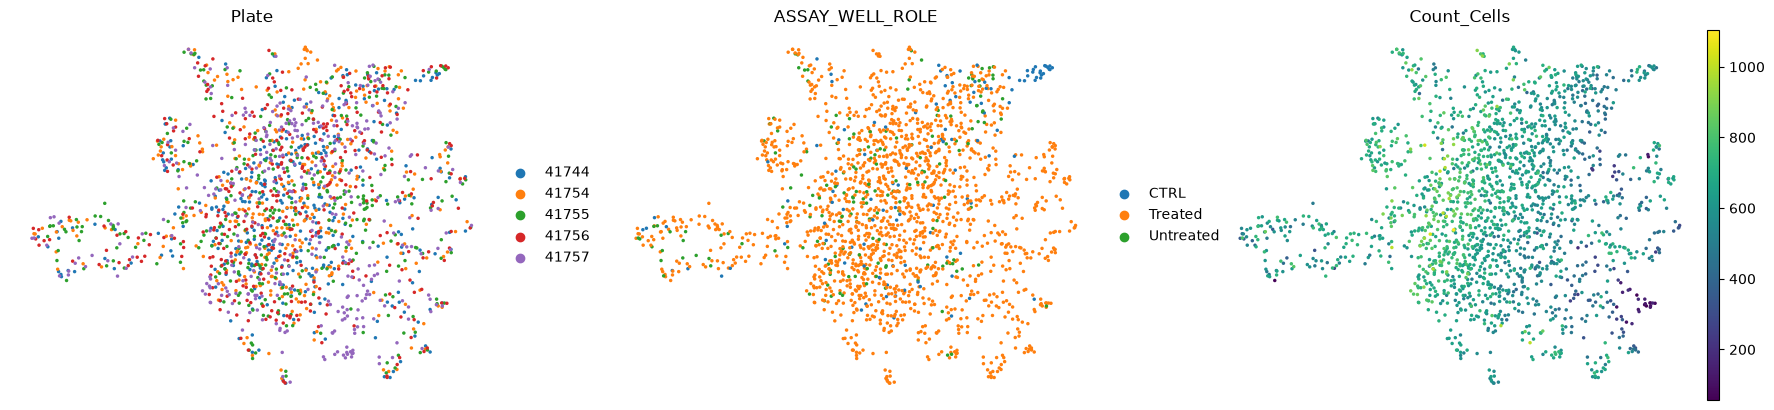

In [8]:
sc.pl.umap(adata, color=["Plate", "ASSAY_WELL_ROLE", "Count_Cells"], ncols=3, frameon=False, size=25)